In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch05. 로지스틱 회귀, 분류 (mnist)</font>

- MNIST : 0부터 9까지의 손글씨 숫자 이미지로 구성된 머신러닝 및 딥러닝 분야의 대표적인 표준 벤치마크 데이터셋

In [66]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist dataset
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 데이터셋 불러오기

## 1. 파일을 통해 불러오기

In [2]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [3]:
print('타겟변수 : ', data[0, 0])
image = data[50, 1:].reshape(28,28)

타겟변수 :  5.0


In [4]:
for row in image:
    for pix in row:
        print(f"{pix:3.0f}", end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 12 56140126175200 96  2  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 35166238254246242253246254 67  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0184182146127 70 30 45 36215175  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 30  0  0  0  0  0  0  0207246 14  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 55251169  1  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 11215232 20  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 20190250 61  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 24118206254248142108 18  0  0  

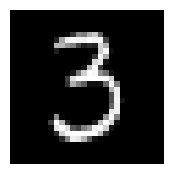

In [5]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [6]:
# 컬러 사진 >> 흑백 모드로 데이터 읽기 (넘파이 배열)

In [ ]:
%pip install opencv-python==4.8.1.78

In [7]:
import cv2
# 사진 이미지를 넘파이 배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE) # 흑백 포맷
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

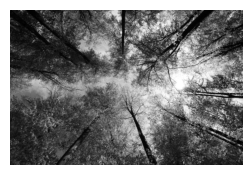

In [8]:
# 넘파이 배열 이미지화
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray') # 컬러맵 적용
plt.axis('off')
plt.show()

## 2. 데이터셋을 통해 가져오기

In [9]:
(X_train, y_train),(X_test, y_test) = mnist.load_data() # 6만, 1만개의 학습, 시험 데이터셋으로 분리되어 로드됨

# 1. 데이터 전처리

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [11]:
value, counts = np.unique(y_train, return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

2


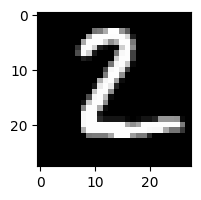

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [12]:
print(y_test[1])
plt.imshow(X_test[1], cmap='gray')
plt.show()
for row in X_test[1]:
    for pix in row:
        print(f"{pix:3.0f}", end='')
    print()

In [13]:
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [14]:
print('학습 데이터셋 :', X_train.shape, y_train.shape)
print('검증 데이터셋 :', X_val.shape, y_val.shape)
print('시험 데이터셋 :', X_test.shape, y_test.shape)

학습 데이터셋 : (50000, 28, 28) (50000,)
검증 데이터셋 : (10000, 28, 28) (10000,)
시험 데이터셋 : (10000, 28, 28) (10000,)


In [15]:
# 입력 변수 (n, 28, 28) >> (n, 28*28) >> 스케일 조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X = X_val.reshape(10000, 784).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [16]:
# 종속변수 : 분류분석을 위한 원-핫 인코딩 (to_categorical(), pd.getdummies() 등 활용)
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [17]:
# train : 임의의 700개, val : 임의의 300개 추출 (수업 중 시간 절약)
train_idx = np.random.choice(50000, 700, replace=False) # 비복원추출(중복x)
val_idx = np.random.choice(10000, 300, replace=False)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X = val_X[val_idx]
val_Y = val_Y[val_idx]

# 2. 모델 구성 & 학습과정 설정 & 학습

In [45]:
model = Sequential(name="mnist_seq")
model.add(Input(shape=(784,)))

model.add(Dense(units=128, activation='elu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='elu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

hist = model.fit(train_X, train_Y,
                epochs=200,
                batch_size=64,
                validation_data=(val_X, val_Y),
                verbose=1)

Epoch 1/200
11/11 [==============================] - 2s 42ms/step - loss: 5.0334 - accuracy: 0.3443 - val_loss: 4.1881 - val_accuracy: 0.6033
Epoch 2/200
11/11 [==============================] - 0s 9ms/step - loss: 3.5530 - accuracy: 0.6971 - val_loss: 3.5785 - val_accuracy: 0.7067
Epoch 3/200
11/11 [==============================] - 0s 9ms/step - loss: 3.0893 - accuracy: 0.7786 - val_loss: 3.2152 - val_accuracy: 0.7700
Epoch 4/200
11/11 [==============================] - 0s 8ms/step - loss: 2.7544 - accuracy: 0.8214 - val_loss: 2.9540 - val_accuracy: 0.8133
Epoch 5/200
11/11 [==============================] - 0s 9ms/step - loss: 2.5113 - accuracy: 0.8443 - val_loss: 2.7531 - val_accuracy: 0.8133
Epoch 6/200
11/11 [==============================] - 0s 9ms/step - loss: 2.2999 - accuracy: 0.8614 - val_loss: 2.6021 - val_accuracy: 0.8200
Epoch 7/200
11/11 [==============================] - 0s 10ms/step - loss: 2.1379 - accuracy: 0.8800 - val_loss: 2.4561 - val_accuracy: 0.8367
Epoch 8/200

11/11 [==============================] - 0s 8ms/step - loss: 0.2641 - accuracy: 0.9843 - val_loss: 0.7562 - val_accuracy: 0.8400
Epoch 59/200
11/11 [==============================] - 0s 8ms/step - loss: 0.2553 - accuracy: 0.9857 - val_loss: 0.8129 - val_accuracy: 0.8333
Epoch 60/200
11/11 [==============================] - 0s 9ms/step - loss: 0.2584 - accuracy: 0.9771 - val_loss: 0.8652 - val_accuracy: 0.8167
Epoch 61/200
11/11 [==============================] - 0s 9ms/step - loss: 0.2612 - accuracy: 0.9757 - val_loss: 0.8441 - val_accuracy: 0.7900
Epoch 62/200
11/11 [==============================] - 0s 8ms/step - loss: 0.2662 - accuracy: 0.9714 - val_loss: 0.8413 - val_accuracy: 0.8167
Epoch 63/200
11/11 [==============================] - 0s 10ms/step - loss: 0.2631 - accuracy: 0.9786 - val_loss: 0.7713 - val_accuracy: 0.8500
Epoch 64/200
11/11 [==============================] - 0s 10ms/step - loss: 0.2601 - accuracy: 0.9757 - val_loss: 0.8726 - val_accuracy: 0.8033
Epoch 65/200
11/1

11/11 [==============================] - 0s 11ms/step - loss: 0.1940 - accuracy: 0.9857 - val_loss: 0.9362 - val_accuracy: 0.8133
Epoch 116/200
11/11 [==============================] - 0s 9ms/step - loss: 0.1941 - accuracy: 0.9829 - val_loss: 0.9783 - val_accuracy: 0.8033
Epoch 117/200
11/11 [==============================] - 0s 9ms/step - loss: 0.2121 - accuracy: 0.9786 - val_loss: 1.0763 - val_accuracy: 0.7867
Epoch 118/200
11/11 [==============================] - 0s 10ms/step - loss: 0.1925 - accuracy: 0.9786 - val_loss: 1.0960 - val_accuracy: 0.7967
Epoch 119/200
11/11 [==============================] - 0s 10ms/step - loss: 0.2043 - accuracy: 0.9814 - val_loss: 1.1627 - val_accuracy: 0.7633
Epoch 120/200
11/11 [==============================] - 0s 9ms/step - loss: 0.2251 - accuracy: 0.9729 - val_loss: 0.8867 - val_accuracy: 0.8167
Epoch 121/200
11/11 [==============================] - 0s 9ms/step - loss: 0.2156 - accuracy: 0.9771 - val_loss: 0.9195 - val_accuracy: 0.8100
Epoch 122/

11/11 [==============================] - 0s 10ms/step - loss: 0.2277 - accuracy: 0.9729 - val_loss: 0.9641 - val_accuracy: 0.8267
Epoch 173/200
11/11 [==============================] - 0s 9ms/step - loss: 0.2191 - accuracy: 0.9771 - val_loss: 1.0490 - val_accuracy: 0.8000
Epoch 174/200
11/11 [==============================] - 0s 9ms/step - loss: 0.2254 - accuracy: 0.9729 - val_loss: 0.9539 - val_accuracy: 0.8100
Epoch 175/200
11/11 [==============================] - 0s 11ms/step - loss: 0.2229 - accuracy: 0.9800 - val_loss: 1.0127 - val_accuracy: 0.8067
Epoch 176/200
11/11 [==============================] - 0s 10ms/step - loss: 0.2168 - accuracy: 0.9800 - val_loss: 0.9611 - val_accuracy: 0.8133
Epoch 177/200
11/11 [==============================] - 0s 12ms/step - loss: 0.2104 - accuracy: 0.9800 - val_loss: 0.9765 - val_accuracy: 0.8200
Epoch 178/200
11/11 [==============================] - 0s 14ms/step - loss: 0.2096 - accuracy: 0.9729 - val_loss: 0.9629 - val_accuracy: 0.8067
Epoch 17

# 3. 모델 시각화 & 평가

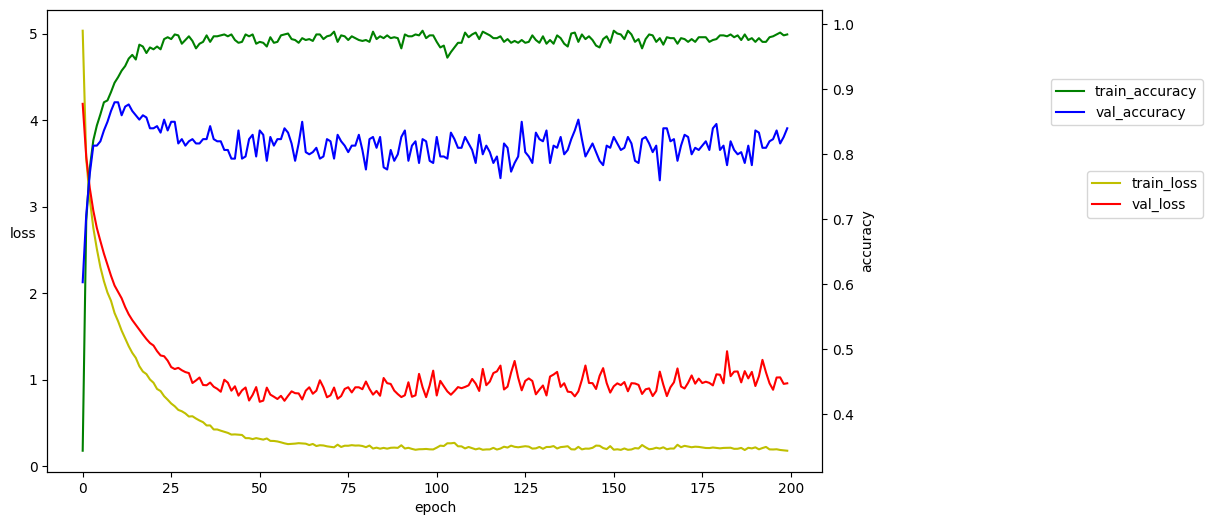

In [46]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

In [41]:
loss, accuracy = model.evaluate(test_X, test_Y)
print(f'loss : {loss:.2f}')
print(f'정확도 : {accuracy*100:.2f}%')

313/313 [==============================] - 1s 3ms/step - loss: 1.0795 - accuracy: 0.8238
loss : 1.08
정확도 : 82.38%


# accuracy control
- 위 모델(DNN)의 accuracy 높이기
1. 데이터 추가 확보
2. 모델 수정 (레이어 추가, units 증가)
 - 과적합 방지(validation data, 활성화 함수를 relu 계열, tahn, Dropout, 배치정규화, L2 규제 등)
3. epoch 및 optimizer 변경

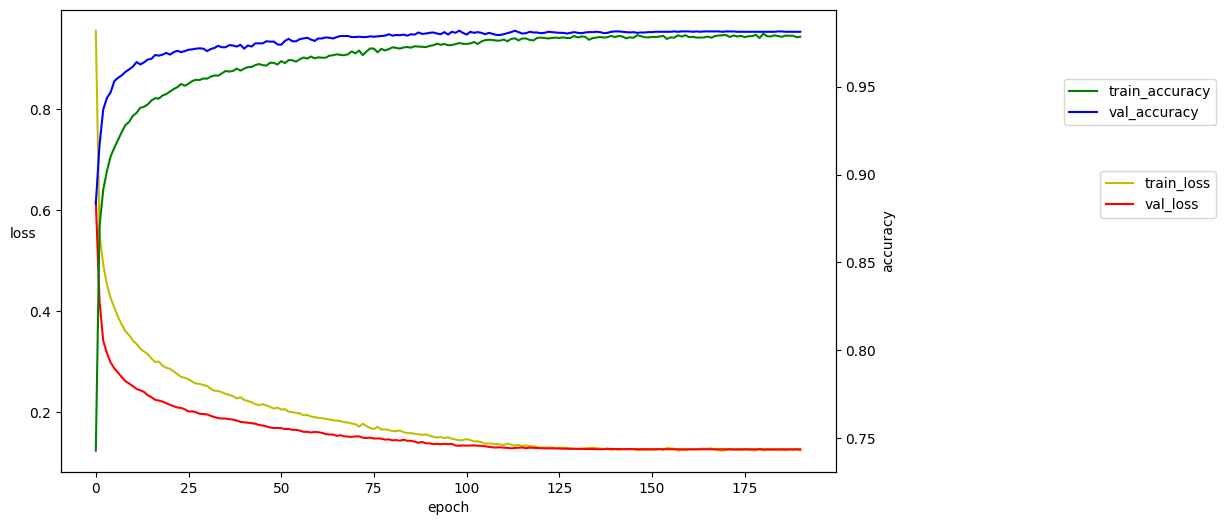

313/313 [==============================] - 1s 3ms/step - loss: 0.1248 - accuracy: 0.9807
loss : 0.12
accuracy : 98.07%
CPU times: total: 24min 8s
Wall time: 6min 18s


In [69]:
%%time
# 데이터 생성
(X_train, y_train),(X_test, y_test) = mnist.load_data()

X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

# 데이터 전처리
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X = X_val.reshape(10000, 784).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)

# # 수업용 데이터 사이즈 조정
# train_idx = np.random.choice(50000, 20000, replace=False)
# val_idx = np.random.choice(10000, 5000, replace=False)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# y_train_sub = y_train[train_idx]

val_X = val_X[val_idx]
val_Y = val_Y[val_idx]

# 모델 생성
model = Sequential(name="mnist_seq")
model.add(Input(shape=(784,)))

model.add(Dense(units=256, activation='elu', kernel_regularizer=l2(0.0002)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(units=128, activation='gelu', kernel_regularizer=l2(0.0002)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='elu', kernel_regularizer=l2(0.0002)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=10, activation='softmax'))

# 학습 과정 설정
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model.compile(loss='categorical_crossentropy',
              optimizer=sgd_optimizer,
              metrics=['accuracy'])

# 클래스 불균형 극복
unique_classes = np.unique(y_train_sub)

class_weight = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_sub
)

class_weight_dict = dict(enumerate(class_weight))

# 콜백 설정
lr_reduce = [
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
            ]

# 학습
hist = model.fit(train_X, train_Y,
                epochs=200,
                batch_size=512,
                validation_data=(val_X, val_Y),
                class_weight=class_weight_dict,
                callbacks=[lr_reduce],
                verbose=0)

# 시각화
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

# 평가
loss, accuracy = model.evaluate(test_X, test_Y)
print(f'loss : {loss:.2f}')
print(f'accuracy : {accuracy*100:.2f}%')

In [70]:
# 교차표
y_test
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1) == y_test)

True

In [72]:
y_hat = model.predict(test_X).argmax(axis=1)
y_hat

313/313 [==============================] - 1s 3ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [74]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,970,1,2,1,0,1,3,1,1,0
1,0,1124,3,1,0,0,2,1,4,0
2,5,1,1011,3,2,0,2,5,3,0
3,0,0,4,996,0,2,0,4,3,1
4,1,0,1,1,959,0,6,2,1,11
5,2,0,0,6,1,871,5,1,4,2
6,4,3,0,0,4,3,943,0,1,0
7,2,4,10,3,1,0,0,999,2,7
8,6,1,1,3,3,2,2,2,950,4


In [75]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[ 970,    1,    2,    1,    0,    1,    3,    1,    1,    0],
       [   0, 1124,    3,    1,    0,    0,    2,    1,    4,    0],
       [   5,    1, 1011,    3,    2,    0,    2,    5,    3,    0],
       [   0,    0,    4,  996,    0,    2,    0,    4,    3,    1],
       [   1,    0,    1,    1,  959,    0,    6,    2,    1,   11],
       [   2,    0,    0,    6,    1,  871,    5,    1,    4,    2],
       [   4,    3,    0,    0,    4,    3,  943,    0,    1,    0],
       [   2,    4,   10,    3,    1,    0,    0,  999,    2,    7],
       [   6,    1,    1,    3,    3,    2,    2,    2,  950,    4],
       [   4,    2,    0,    4,    6,    1,    1,    5,    2,  984]],
      dtype=int64)

In [77]:
# 예측이 틀린 개수
10000 - accuracy * 10000

192.99983978271484

# 콜백 함수 1: 로그 출력

In [ ]:
%%time
# 데이터 생성
(X_train, y_train),(X_test, y_test) = mnist.load_data()

X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

# 데이터 전처리
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X = X_val.reshape(10000, 784).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)

# 수업용 데이터 사이즈 조정
train_idx = np.random.choice(50000, 10000, replace=False)
val_idx = np.random.choice(10000, 2000, replace=False)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
y_train_sub = y_train[train_idx]

val_X = val_X[val_idx]
val_Y = val_Y[val_idx]

# 모델 생성
model = Sequential(name="mnist_seq")
model.add(Input(shape=(784,)))

model.add(Dense(units=256, activation='elu', kernel_regularizer=l2(0.0002)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(units=64, activation='elu', kernel_regularizer=l2(0.0002)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=10, activation='softmax'))

# 학습 과정 설정
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

class_weight_dict = dict(enumerate(class_weight))

# 학습
hist = model.fit(train_X, train_Y,
                epochs=200,
                batch_size=256,
                validation_data=(val_X, val_Y),
                verbose=0)

# 시각화
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

# 평가
loss, accuracy = model.evaluate(test_X, test_Y)
print(f'loss : {loss:.2f}')
print(f'accuracy : {accuracy*100:.2f}%')